# Task 4 - Customer Churn / Sales Trend Analysis

## Objective
Perform end-to-end analysis on an e-commerce sales dataset to identify
customer segments, sales trends, product performance, and actionable
business insights.

## Key Areas
- Data cleaning and preprocessing
- Feature engineering and date extraction
- Customer segment analysis
- Sales and profit analysis
- Monthly and yearly sales trends
- Pivot table analysis
- Business recommendations

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [19]:
import pandas as pd

df = pd.read_csv('/content/Superstore.csv')

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and Columns: (500, 14)


,Order ID,Order Date,Customer Name,Segment,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Region,City,State
0,ORD-10085,2024-01-01,Customer 063,Consumer,Office Supplies,Storage,Notebook,257.53,6,0.00,47.68,Central,Delhi,Delhi
1,ORD-10135,2024-01-02,Customer 033,Home Office,Office Supplies,Binders,File Folder,311.12,4,0.20,21.83,West,Mumbai,Maharashtra
2,ORD-10159,2024-01-03,Customer 026,Home Office,Office Supplies,Binders,Printer Paper,259.83,3,0.10,45.55,West,Mumbai,Maharashtra
3,ORD-10297,2024-01-05,Customer 052,Consumer,Office Supplies,Binders,File Folder,61.35,1,0.00,13.41,South,Bengaluru,Karnataka
4,ORD-10009,2024-01-05,Customer 014,Consumer,Furniture,Bookcases,Bookshelf,245.17,1,0.15,8.60,East,Kolkata,West Bengal


In [20]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Order ID', 'Order Date', 'Customer Name', 'Segment', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Region', 'City', 'State']


In [21]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check date range
print("Date range:")
print(df['Order Date'].min(), "to", df['Order Date'].max())

Date range:
2024-01-01 00:00:00 to 2025-12-31 00:00:00


In [22]:
# Feature engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter

print("New features created successfully!")
print(df[['Order Date', 'Year', 'Month', 'Month_Name', 'Quarter']].head())

New features created successfully!
  Order Date  Year  Month Month_Name  Quarter
0 2024-01-01  2024      1    January        1
1 2024-01-02  2024      1    January        1
2 2024-01-03  2024      1    January        1
3 2024-01-05  2024      1    January        1
4 2024-01-05  2024      1    January        1


In [23]:
# Monthly sales trend
monthly_sales = df.groupby(
    ['Year', 'Month']
)['Sales'].sum().reset_index()

monthly_sales['Year_Month'] = (
    monthly_sales['Year'].astype(str) + '-' +
    monthly_sales['Month'].astype(str).str.zfill(2)
)

print(monthly_sales.head(12))

    Year  Month     Sales Year_Month
0   2024      1  23187.03    2024-01
1   2024      2  23660.16    2024-02
2   2024      3  25212.08    2024-03
3   2024      4  25382.15    2024-04
4   2024      5  13607.02    2024-05
5   2024      6   8574.98    2024-06
6   2024      7  21961.00    2024-07
7   2024      8  27326.78    2024-08
8   2024      9  12708.25    2024-09
9   2024     10  13023.44    2024-10
10  2024     11  21249.02    2024-11
11  2024     12  17023.34    2024-12


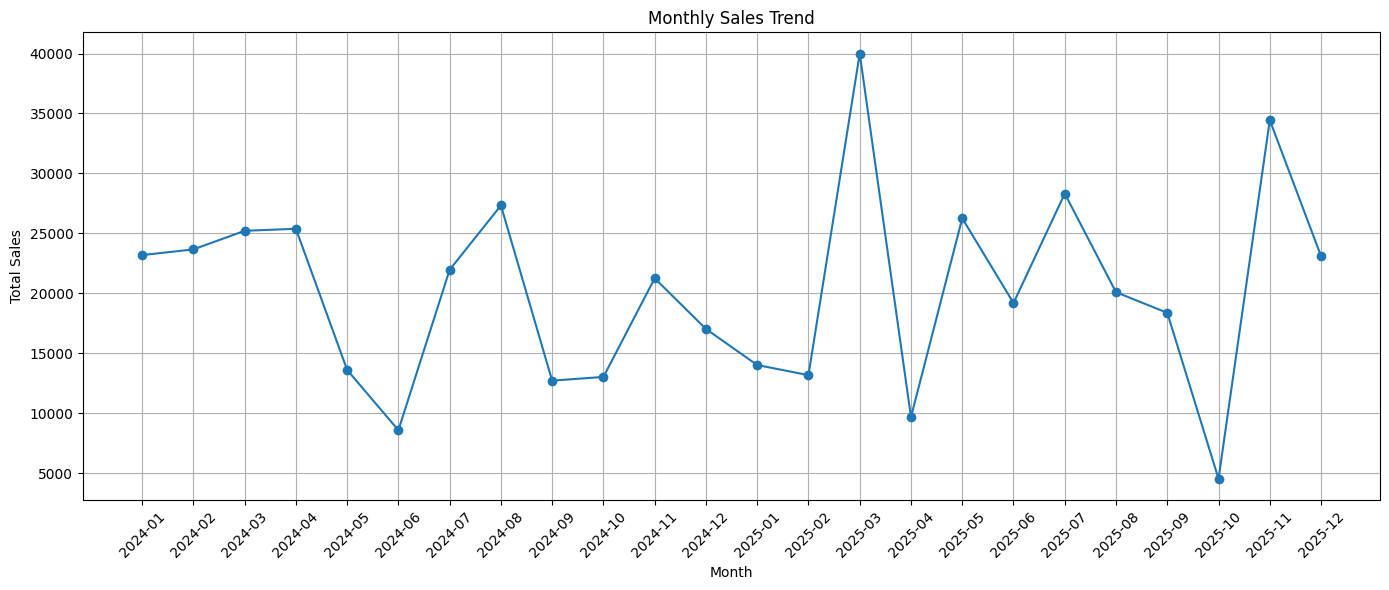

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['Year_Month'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [25]:
# Yearly sales analysis
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

print(yearly_sales)



   Year      Sales
0  2024  232915.25
1  2025  251144.13


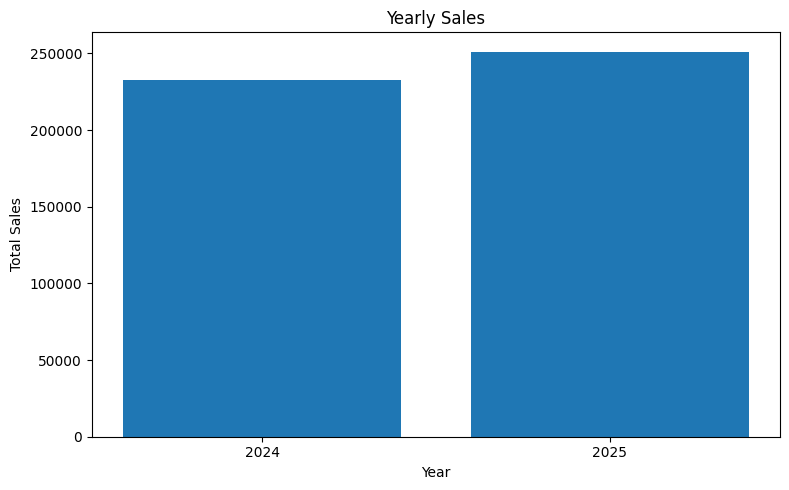

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    yearly_sales['Year'].astype(str),
    yearly_sales['Sales']
)

plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

In [27]:
segment_sales = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum')
).reset_index()

print(segment_sales)

       Segment  Total_Sales  Total_Profit  Total_Quantity
0     Consumer    258702.56      30843.67            1018
1    Corporate    160572.76      16812.78             665
2  Home Office     64784.06       6911.07             304


In [28]:
category_sales = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum')
).reset_index()

print(category_sales)

          Category  Total_Sales  Total_Profit  Total_Quantity
0        Furniture    132772.28       9524.54             638
1  Office Supplies     36907.93       5302.83             668
2       Technology    314379.17      39740.15             681


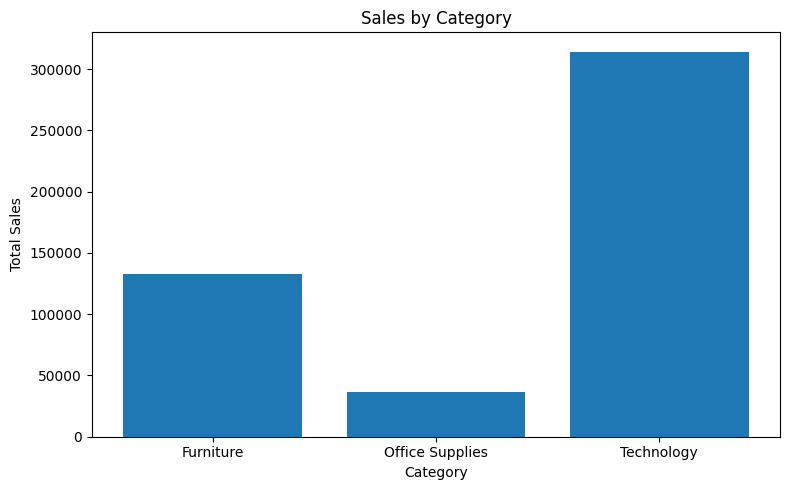

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_sales['Category'],
    category_sales['Total_Sales']
)

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

In [30]:
profit_by_category = df.groupby('Category')['Profit'].sum().reset_index()

print(profit_by_category)

          Category    Profit
0        Furniture   9524.54
1  Office Supplies   5302.83
2       Technology  39740.15


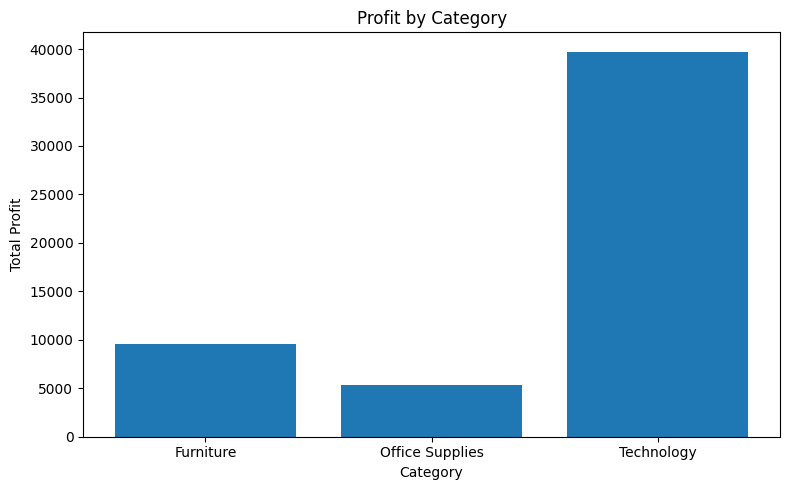

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    profit_by_category['Category'],
    profit_by_category['Profit']
)

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')

plt.tight_layout()
plt.show()

In [32]:
pivot_sales = pd.pivot_table(
    df,
    values='Sales',
    index='Category',
    columns='Year',
    aggfunc='sum'
)

print(pivot_sales)

Year                  2024       2025
Category                             
Furniture         66077.76   66694.52
Office Supplies   19202.27   17705.66
Technology       147635.22  166743.95


In [33]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(
    ascending=False
).head(10)

print(top_products)

Product Name
Keyboard            94807.57
Monitor             71326.05
Laptop              54511.56
Tablet              47461.61
Smartphone          46272.38
Bookshelf           29276.87
Conference Table    27974.43
Cabinet             26481.95
Office Chair        25199.95
Desk                23839.08
Name: Sales, dtype: float64


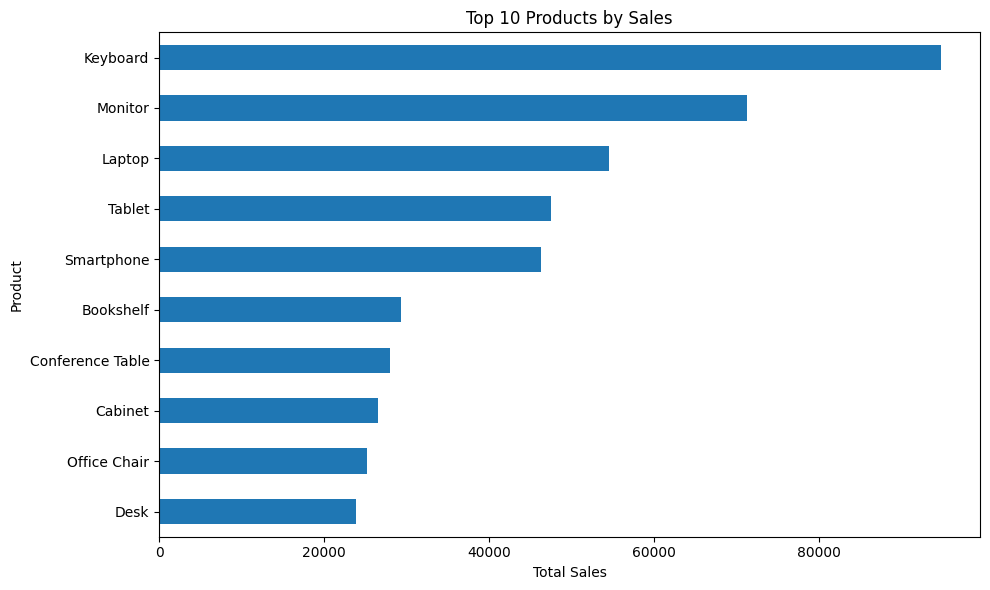

In [34]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

## Business Recommendations

1. Focus on products and categories with consistently high sales.
2. Identify low-profit products and review their pricing and discount strategies.
3. Monitor monthly and yearly sales trends for better inventory planning.
4. Focus marketing efforts on high-performing customer segments.
5. Analyze regional sales performance to identify growth opportunities.

# Final Project Summary

## Sales Trend Analysis

This project analyzes Superstore sales data to identify important sales and profit trends.

### Key Analysis Performed
- Data cleaning and preprocessing
- Date feature extraction
- Customer segment analysis
- Sales and profit analysis
- Monthly sales trend analysis
- Yearly sales trend analysis
- Category-wise sales analysis
- Profit analysis
- Pivot table analysis
- Business recommendations

### Business Insights
- Sales performance varies across different months and years.
- Technology contributes significantly to overall sales.
- Customer segments show different purchasing patterns.
- Product and category performance can help improve inventory planning.
- Sales and profit trends can support better business decisions.

### Conclusion
The analysis provides useful insights into sales performance, customer behavior, product categories, and business trends. These insights can be used for inventory planning, marketing decisions, and improving overall business performance.